# ChordCutter Bot


## Dataset

[Music Bench](https://huggingface.co/datasets/amaai-lab/MusicBench)

## Idea

<strong>Input</strong>: audio file

<strong>Output</strong>: chord sheet

1. Input audio file
2. Audio file gets split into segments (ex: 10s)
3. Each segment gets passed into the NN. Outputs the chord progression and the timestamp
4. Pass the same segment into another NN that generates the lyrics and timestamps
5. Overlay the chords and lyrics based on the timestamps

### Components

1. Audio to chords NN
2. Audio to lyrics NN
3. Chord sheet assembler
4. Data preprocessor (ex: .mp3 to .wav?)


### Data Loading


In [1]:
# Libraries
import os
import torch
import requests
import tarfile
import librosa
from io import BytesIO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from datasets import load_dataset

c:\Users\Sean\Documents\GitHub\ChordCutterBot\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ds = load_dataset("amaai-lab/MusicBench")
ds

DatasetDict({
    train: Dataset({
        features: ['dataset', 'location', 'main_caption', 'alt_caption', 'prompt_aug', 'prompt_ch', 'prompt_bt', 'prompt_bpm', 'prompt_key', 'beats', 'bpm', 'chords', 'chords_time', 'key', 'keyprob', 'is_audioset_eval_mcaps'],
        num_rows: 52768
    })
    test: Dataset({
        features: ['dataset', 'location', 'main_caption', 'alt_caption', 'prompt_aug', 'prompt_ch', 'prompt_bt', 'prompt_bpm', 'prompt_key', 'beats', 'bpm', 'chords', 'chords_time', 'key', 'keyprob', 'is_audioset_eval_mcaps'],
        num_rows: 800
    })
})

In [ ]:
train_df = ds['train'].to_pandas()
test_df = ds['test'].to_pandas()

train_df
# test_df

# TODO: remove np.nan from chords list

,dataset,location,main_caption,alt_caption,prompt_aug,prompt_ch,prompt_bt,prompt_bpm,prompt_key,beats,bpm,chords,chords_time,key,keyprob,is_audioset_eval_mcaps
0,MusicBench,data_aug2/-0SdAVK79lg_1.wav,This mellow instrumental track showcases a dom...,This song features an electric guitar as the m...,,The chord progression in this song is E.,The beat counts to 4.,The bpm is 112.0.,The key of this song is E major.,"[[0.37212133669135816, 0.9070457581851855, 1.4...",112.0,[E],[0.5400400339790407],"[E, major]",[0.8934084177017212],False
1,MusicBench,data_aug2/-0SdAVK79lg_2.wav,This relaxing song is perfect for a coffee sho...,This song features an electric guitar as the m...,,The chord progression in this song is E.,The beat is 4.,The song is played at the pace of Vivace.,This song is in the key of E major.,"[[0.2658142022146419, 0.6479221178981897, 1.04...",157.0,[E],[0.4485947212378337],"[E, major]",[0.8934084177017212],False
2,MusicBench,data_aug2/-0SdAVK79lg_3.wav,This laid-back instrumental track is perfect f...,This song features an electric guitar as the m...,,The chord progression in this song is E.,The beat counts to 4.,The bpm is 151.0.,The key of this song is E major.,"[[0.2754422138603508, 0.6713903962846051, 1.08...",151.0,[E],[0.3861310098244245],"[E, major]",[0.8934084177017212],False
3,MusicBench,data_aug2/-0SdAVK79lg_4.wav,This is a relaxing song that features an elect...,This song features an electric guitar as the m...,,The chord progression in this song is E.,The beat is 4.,The song is played at the pace of Vivace.,This song is in the key of E major.,"[[0.2801938173601484, 0.6829724298153618, 1.10...",148.0,[E],[0.33809850513698275],"[E, major]",[0.8934084177017212],False
4,MusicBench,data_aug2/-0SdAVK79lg_5.wav,This relaxing song is perfect for a coffee sho...,This song features an electric guitar as the m...,,The chord sequence is C#.,The time signature is 4/4.,This song goes at 130.0 beats per minute.,This song is in the key of C# major.,"[[0.32, 0.78, 1.26, 1.74, 2.2, 2.66, 3.12, 3.5...",130.0,[C#],[0.33809850513698275],"[C#, major]",[0.8934084177017212],False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52763,MusicBench,data/zir3uL14ijM.wav,This mellow tune is led by a passionate male v...,The low quality recording features a passionat...,,"The chord progression in this song is E, F#m7,...",The beat is 3.,The bpm is 92.0.,This song is in the key of E major.,"[[0.02, 0.68, 1.38, 2.0, 2.66, 3.3, 3.96, 4.58...",92.0,"[E, F#m7, F#m7b5, E/B]","[0.464399092, 1.30031746, 3.90095238, 6.315827...","[E, major]",[0.8000931739807129],False
52764,MusicBench,data/zjZV0tvur2I.wav,"This song, in the key of G minor and with a te...",The low quality recording features a widely sp...,,The chord sequence is Ab7.,The beat counts to 2.,The tempo of this song is 127.0 beats per minute.,This song is in the key of G minor.,"[[0.28, 0.76, 1.22, 1.72, 2.2, 2.66, 3.16, 3.6...",127.0,[Ab7],[1.30031746],"[G, minor]",[0.7355943918228149],False
52765,MusicBench,data/zjsWFvUkh7M.wav,This Pop Rock song is led by a lively male voc...,A male vocalist sings this energetic song. The...,,"The chord sequence is D, Gm, Daug.",The beat is 3.,This song goes at 110.0 beats per minute.,The key of this song is D minor.,"[[0.02, 0.54, 1.06, 1.58, 2.12, 2.64, 3.18, 3....",110.0,"[D, Gm, Daug]","[0.557278911, 3.622312925, 8.266303854]","[D, minor]",[0.7975711822509766],True
52766,MusicBench,data/zqbHYVH6Wqo.wav,This devotional and spirited instrumental song...,The song is an instrumental. The tempo is medi...,,The chord sequence is F.,The beat is 2.,This song is played in Presto.,The key is F major.,"[[0.28, 0.6, 0.94, 1.28, 1.64, 1.98, 2.32, 2.6...",177.0,[F],[0.464399092],"[F, major]",[0.8479340076446533],False


### Chord Exploration


In [4]:
# Takes in a Series (chords column) and gives a set of unique chords
def get_chord_set(chords: pd.Series) -> set:
    return set(chords.apply(list).explode().unique())

# Returns a list of root chords; simplifies slash chords if necessary
def get_root_chords(chords) -> list:
    return map(lambda x: x.split('/')[0] if is_slash_chord(x) else x, chords)

# Filter for slash chords
def is_slash_chord(chord) -> bool:
    return chord and isinstance(chord, str) and "/" in chord

In [5]:
# Chords exploration
chords = train_df['chords']

# Set of all chords
chords_set = set(get_chord_set(chords))

# Set of all slash chords (ex: C/E)
slash_chords = set(filter(is_slash_chord, chords_set))

# Set of root chords of the slash chords (ex: C from C/E)
root_slash = set(get_root_chords(slash_chords))

# Set of (all chords - slash chords) U (root chords)
root_chords = (chords_set - slash_chords).union(root_slash)

print(f"All Chords:\tsize={len(chords_set)}, {chords_set}")
print(f"Slash Chords:\tsize={len(slash_chords)}, {slash_chords}")
print(f"Root Slash:\tsize={len(root_slash)}, {root_slash}")
print(f"Root Chords:\tsize={len(root_chords)}, {root_chords}")
# The number of root chords is the total number of chords minus the number of slash chords
# (there are no roots from slash chords that do not appear in the set of non-slash chords)

All Chords:	size=292, {'Cm7b5/Bb', 'Bb/Ab', 'Gb/Ab', 'G#/Gb', 'Em7b5/D', 'Dbaug', 'D/F#', 'Cm6', 'Bb/D', 'Ab/Gb', 'F#7', 'D', 'Dm', 'Gb/A#', 'Eb/Bb', 'Cmaj7', 'Bm7', 'C#maj7', 'C#dim', 'G#maj7', 'E6', 'Db/F', 'E7', 'G#6', 'G#7', 'D#6', 'Db7', 'A#m7b5/G#', 'A#m7', 'B/A', 'Gbm7b5/E', 'Baug', 'Cm', 'G#/A#', 'Gbm7', 'A#aug', 'C#aug', 'Db/Ab', 'D#/F', 'Eb/G', 'Daug', 'C#/F', 'G#', 'Dbm6', 'F#m', 'Ebmaj7', 'Dbm7b5', 'G#/D#', 'B/Gb', 'Fm7b5/D#', 'Eb', 'Gdim', 'G#/F#', 'Fdim', 'Gb7', 'Fm6', 'F#maj7', 'Dm7b5', 'Gm7b5/F', 'A#m6', 'C7', 'A', 'Am6', 'D#/G', 'F#m7b5/E', 'C#/D#', 'Ab/Bb', 'Bb7', 'Cm7b5', 'A/G', 'D/C', 'C#m7b5', 'Bbaug', 'C', 'Db/D#', 'Db/G#', 'Dm6', 'Aaug', 'Bm', 'Ab7', 'D#m7', 'Am7b5', 'C/Bb', 'D#/A#', 'A/B', 'G#dim', 'E/G#', 'F#/E', 'Bbm', 'Gb/G#', 'D#m', 'D#dim', 'Em', 'A#m7b5/Ab', 'Gbmaj7', 'C#7/F', 'B/C#', 'Dm7b5/C', 'Dm7', 'Dbm', 'Abmaj7', 'G#aug', 'Fm7b5', 'A#6', 'Fm7b5/Eb', 'A#/C', 'Gaug', 'Gbdim', 'Faug', 'G#m7b5', 'Eb/Db', 'Ab/C', 'C#m7b5/B', 'F#6', 'C#/B', 'E7/G#', 'B', '

In [6]:
num_chord_classes = len(root_chords)
print(num_chord_classes)

172


### Audio Analysis Exploration


In [7]:
def open_audio_file(location='', num=-1):
    ''' 
    Gets the tar file online without reading everything into memory. Iterates through response one file at a time.
    Only considers files (and currently .wav files). Can be used to get a specific file, though this is achieved
    by iterating over every item in the decompressed tar file. Can also be used to get a specific number of files.

    Input
    - location: the filepath (as provided by the "Location" column in the dataset) to retrieve (note: current implementation is very inefficient). Default is the empty string, which will output all files
    - num: the number of files to retrieve, from the beginning. Default is -1, which will output all the files

    Output
    - None
    '''
    url = 'https://huggingface.co/datasets/amaai-lab/MusicBench/resolve/main/MusicBench.tar.gz'
    response = requests.get(url, stream=True)
    print("response received!")
    print(response, '\n')
    retrieved_count = 0
    
    if response.status_code == 200:
        # open tar file as a stream
        with tarfile.open(fileobj=response.raw, mode='r|gz') as tar:
            print("opened tar file!")

            for member in tar:
                # only care about files
                # if location is given, only get that file; otherwise get all files
                if member.isfile() and (member.name == f"datashare/{location}" or not location):
                    file = tar.extractfile(member)
                    print("Type:", type(file))
                    print("File:", file)
                    print(f"File name: {member.name}")

                    file = tar.extractfile(member)
                    print("Extracted file:", file, '\n')

                    # read this file into memory
                    file_bytes = BytesIO(file.read())

                    # only get audio files
                    if member.name.endswith('.wav'):
                        audio_data, sr = librosa.load(file_bytes, sr=None)

                        # metadata
                        print("-----METADATA-----")
                        print(f"Audio length: {len(audio_data)} samples, Sample Rate: {sr}")
                        print(type(audio_data), audio_data.shape)
                        print("audio_data element:", audio_data[0])

                        # sound amplitude
                        plt.plot(audio_data)
                        plt.show()

                        # Mel-frequency cepstral coefficients
                        mfccs = librosa.feature.mfcc(y=audio_data, sr=sr, n_mfcc=13)
                        plt.figure(figsize=(10, 4))
                        librosa.display.specshow(mfccs, sr=sr, x_axis='time')
                        plt.colorbar(label='MFCC')
                        plt.title('MFCCs')
                        plt.show()
                        print("MFCCs:", mfccs.shape)

                        # chroma feature extraction
                        chroma = librosa.feature.chroma_stft(y=audio_data, sr=sr)
                        print("Chroma Shape:", chroma.shape)
                        plt.figure(figsize=(10, 4))
                        librosa.display.specshow(chroma[:, :10], y_axis='chroma', x_axis='time', cmap='coolwarm', sr=sr)
                        plt.colorbar(label='Intensity')
                        plt.title('Chroma Feature Representation')
                        plt.xlabel('Time (seconds)')
                        plt.ylabel('Pitch Class')
                        plt.show()

                        # harmonic-percussive separation
                        harmonic, percussive = librosa.effects.hpss(y=audio_data)

                        plt.figure(figsize=(10, 4))
                        plt.plot(harmonic, label="Harmonic")
                        plt.plot(percussive, label="Percussive")
                        plt.legend()
                        plt.title("Harmonic & Percussive Separation")
                        plt.show()

                        # Constant-Q Transform (CQT)
                        cqt = librosa.cqt(y=audio_data, sr=sr)
                        cqt_db = librosa.amplitude_to_db(abs(cqt))
                        plt.figure(figsize=(10, 4))
                        librosa.display.specshow(cqt_db, sr=sr, x_axis='time', y_axis='cqt_note', cmap='coolwarm')
                        plt.colorbar(label='dB')
                        plt.title('Constant-Q Transform (CQT)')
                        plt.show()

                    file.close()
                    if location:  # stop after finding requested file
                        break
                    else:
                        retrieved_count += 1
                        if retrieved_count == num:
                            break
    else:
        print(f"Failed to download the file: {response.status_code}")

response received!
<Response [200]> 

opened tar file!
Type: <class 'tarfile.ExFileObject'>
File: <ExFileObject name=''>
File name: datashare/data_aug2/u3yOMK8SuRI_1.wav
Extracted file: <ExFileObject name=''> 

-----METADATA-----
Audio length: 160000 samples, Sample Rate: 16000
<class 'numpy.ndarray'> (160000,)
audio_data element: 0.0


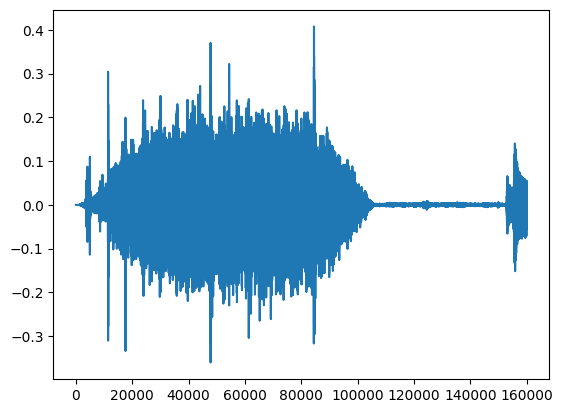

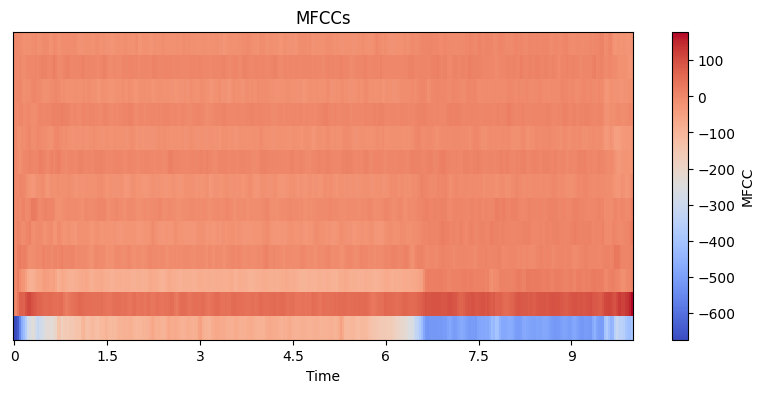

MFCCs: (13, 313)
Chroma Shape: (12, 313)


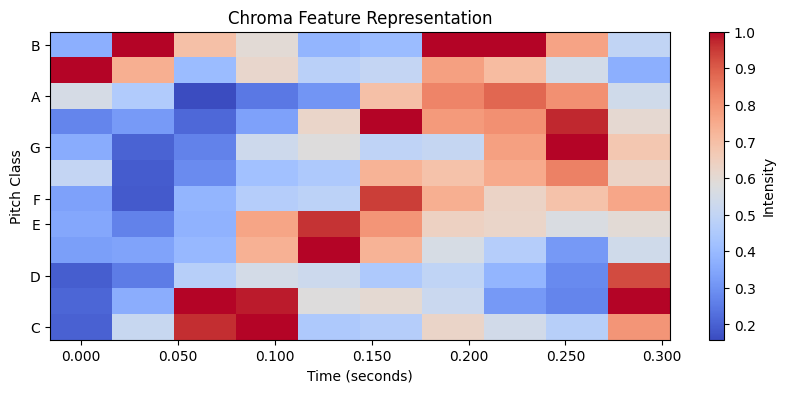

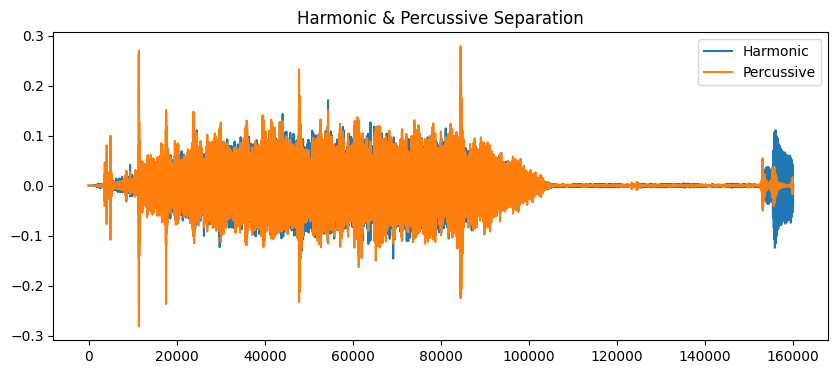

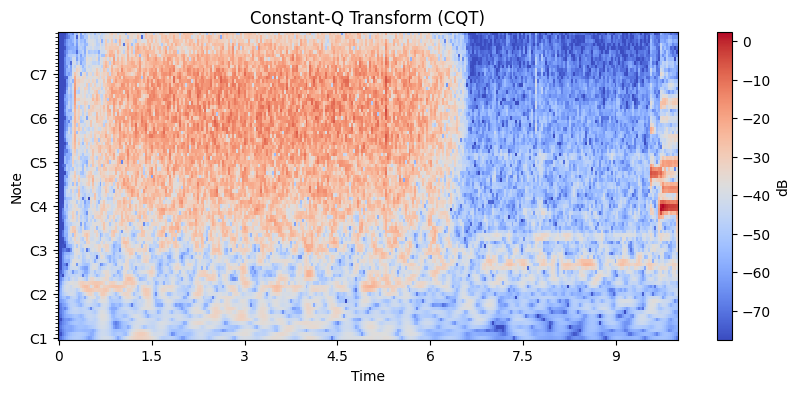

In [8]:
# get specific number of audio files
open_audio_file(num=1)

response received!
<Response [200]> 

opened tar file!
Type: <class 'tarfile.ExFileObject'>
File: <ExFileObject name=''>
File name: datashare/data_aug2/u3yOMK8SuRI_1.wav
Extracted file: <ExFileObject name=''> 

-----METADATA-----
Audio length: 160000 samples, Sample Rate: 16000
<class 'numpy.ndarray'> (160000,)
audio_data element: 0.0


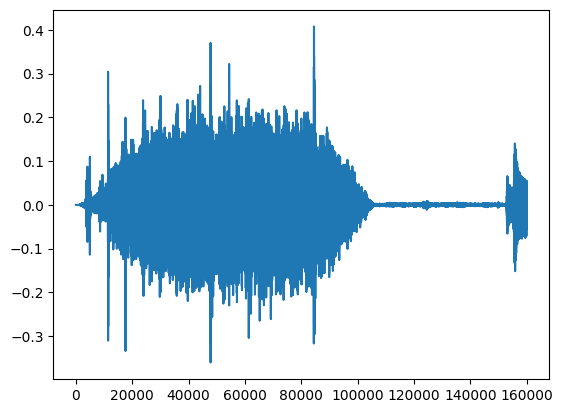

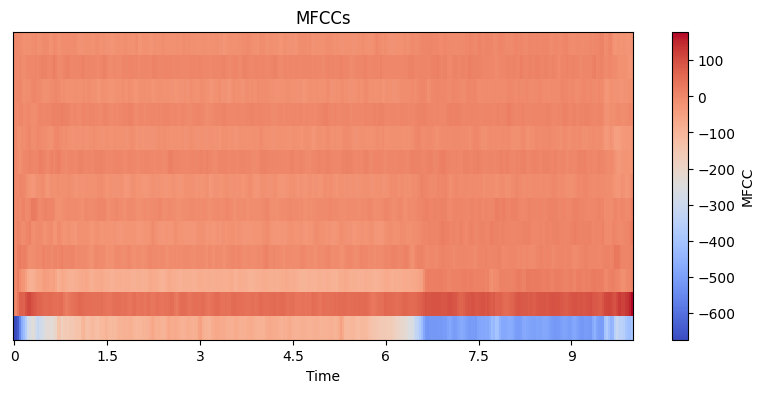

MFCCs: (13, 313)
Chroma Shape: (12, 313)


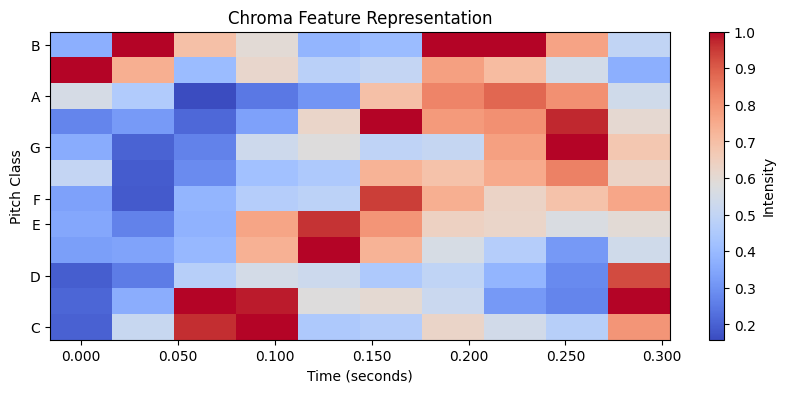

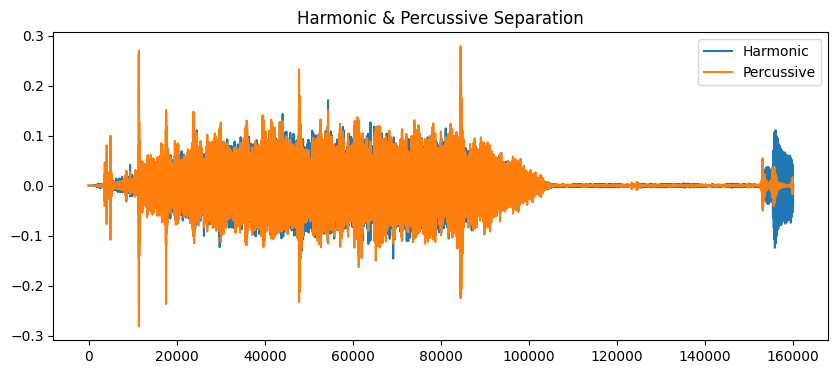

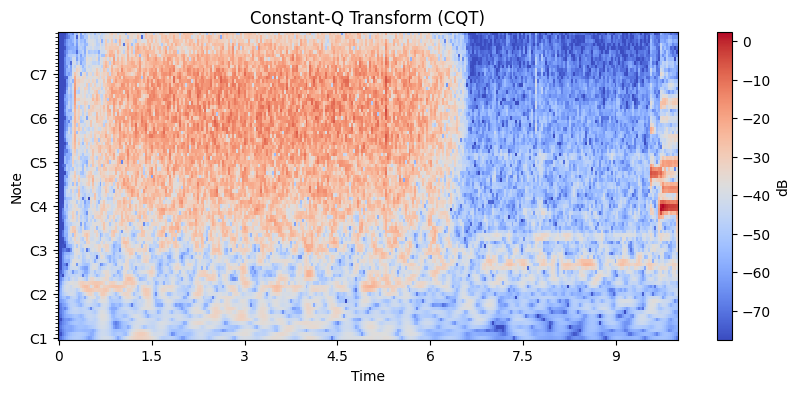

In [9]:
# get audio file by location (see table)
open_audio_file("data_aug2/u3yOMK8SuRI_1.wav")

### Chroma Features Preprocessing


In [10]:
def compute_and_save_chromas(audio_paths, output_dir, sr=None):
    """
    For each filepath in audio_paths:
      - compute chroma
      - save as .npy in output_dir
    """
    os.makedirs(output_dir, exist_ok=True)
    for audio_path in audio_paths:
        # 1) Load the audio
        audio_data, sr_ = librosa.load('datashare/' + audio_path, sr=sr)
        audio_data = librosa.util.normalize(audio_data)

        # 2) Compute chroma (Shape: (12, time_frames))
        chroma_features = librosa.feature.chroma_stft(y=audio_data, sr=sr_)
        # Normalize or scale if you want
        chroma_features /= np.max(chroma_features)

        # 3) Save .npy
        #    e.g. if audio_path = "/path/to/audio/song.wav"
        #    you'll get output_dir + "song.npy"
        filename_stem = os.path.splitext(os.path.basename(audio_path))[0]
        out_path = os.path.join(output_dir, filename_stem + ".npz")
        np.savez(out_path, chroma=chroma_features, sr=sr_)

        # 4) Save sr

    print("Precomputation complete!")

In [11]:
# NOTE: you need to run this once to pre-compute the chroma features locally.
# This makes training faster, but there are too many chromas to include in the repo
# compute_and_save_chromas(train_df['location'], "chroma_features")
# compute_and_save_chromas(test_df['location'], "chroma_features_test")

## Library Functions

#### Tokenizing


In [12]:
# Preprocessing - Tokenizing
idx_to_chord = list(root_chords)  # mapping of index-to-chords
idx_to_chord = ['<PAD>', '<NULL>'] + idx_to_chord
chord_to_idx = {chord: i for i, chord in enumerate(idx_to_chord)}
print("idx_to_chord:\t", idx_to_chord)
print("chord_to_idx:\t", chord_to_idx)

idx_to_chord:	 ['<PAD>', '<NULL>', 'Gb', 'Eaug', 'Abm7b5', 'Dbaug', 'Ddim', 'Abm6', 'Cm6', 'F#7', 'E', 'Adim', 'D', 'Dm', 'Abm7', 'Bbm7', 'G#m6', 'Gm7', 'F7', 'Ebm7', 'Bm7', 'Cmaj7', 'C#dim', 'C#maj7', 'G#maj7', 'E6', 'C#7', 'E7', 'Amaj7', 'G#6', 'G#7', 'D#6', 'Db7', 'Ab', nan, 'Dbdim', 'Ab6', 'C#m', 'D#7', 'A#m7', 'G#m7', 'Baug', 'Cm', 'F#m6', 'Gbm7', 'A#aug', 'C#aug', 'Gm', 'A#', 'Cdim', 'Ebm6', 'D#', 'Daug', 'G#', 'Dbm6', 'Caug', 'F#m', 'Ebmaj7', 'Dbm7b5', 'Cm7', 'Em6', 'Eb', 'Bbmaj7', 'Gdim', 'Fdim', 'Bdim', 'Gb7', 'Dbm7', 'Fm6', 'Am', 'F#maj7', 'Gbm', 'Dm7b5', 'Am7', 'A7', 'A#m6', 'C7', 'Bm6', 'A', 'Am6', 'Em7', 'Abdim', 'Bb7', 'Cm7b5', 'C#m7b5', 'Bbaug', 'C', 'Eb7', 'Ebdim', 'Dm6', 'F6', 'Aaug', 'Bm', 'Gm7b5', 'Ab7', 'D#m7', 'Am7b5', 'C#m6', 'G#dim', 'B7', 'D#aug', 'Bbm', 'Bb6', 'D#m', 'Dbmaj7', 'D#dim', 'Em', 'Gbmaj7', 'Gmaj7', 'Dmaj7', 'Bb', 'Dm7', 'Dbm', 'Abmaj7', 'G#aug', 'Fm7b5', 'A#6', 'Em7b5', 'Gaug', 'F', 'Gbdim', 'Faug', 'Gbm6', 'G#m7b5', 'Bbm7b5', 'Fm7', 'F#6', 'A6', 'B

### Functions

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = torch.device("mps")

# given list of chord indices and the time of their occurence,
# return a list of chord indices for each time frame
def get_chords_per_frame(chords:list, chord_times:list, num_frames:int, hop_length=512, sr=22050) -> list:
    res = []
    j = 0
    chord = chord_to_idx['<NULL>']
    for i in range(num_frames):
        seconds = frame_to_time(i, hop_length, sr)

        # update the chord if there are more chords and
        # the time frame is in the next chord
        if j < len(chord_times) and seconds >= chord_times[j]:
            chord = chords[j]
            j += 1
        res.append(chord)
    return res

# converts timeframe to time in seconds
def frame_to_time(frame_idx:int, hop_length=512, sr=22050) -> float:
    return (frame_idx * hop_length) / sr

# takes pd.Series of chord progressions, returns a list of token indices
def tokenize_chord_labels(chord_labels: pd.Series) -> list:
    root_chord_labels = [list(get_root_chords(label)) for label in chord_labels]
    root_chord_idx = [chord_labels_to_idx(root_labels) for root_labels in root_chord_labels]
    return root_chord_idx

# helper function to convert one chord progression to a list of token indices
def chord_labels_to_idx(chord_labels: list) -> list:
    return [chord_to_idx[label] for label in chord_labels]

def chroma_extraction(file):
    with open(file, "rb") as file_bytes:
        # load and normalize audio file
        audio_data, sr = librosa.load(file, sr=None)
        audio_data = librosa.util.normalize(audio_data)

        # get chroma features (12, T) where T=frames
        chroma_features = librosa.feature.chroma_stft(y=audio_data, sr=sr)
        chroma_features /= np.max(chroma_features)  # scale [0, 1]

        chroma_tensor = torch.tensor(chroma_features, dtype=torch.float32).to(device)
        return chroma_tensor, chroma_tensor.shape[1], sr  # Shape=(12, sequence_length, sr)
    

# takes chord indices (argmax of model output),
# returns a collapsed list of the chords and their times
def process_chord_progression(chord_idx, sr=22050):
    chords = []
    times = []
    prev = float("-inf")
    for frame_idx, idx in enumerate(chord_idx):
        if idx != prev:
            chords.append(idx_to_chord[idx])
            times.append(frame_to_time(frame_idx, sr=sr))
            prev = idx
    
    return chords, times

# load checkpoint to model and optimizer
def load_checkpoint(model, opt, checkpoint_path, device):
    checkpoint = torch.load(checkpoint_path, map_location=device)

    model.load_state_dict(checkpoint['model_state_dict'])
    opt.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    previous_loss = checkpoint['loss']
    return model, opt, start_epoch, previous_loss

### Evaluation

In [58]:
# TODO: include audio file in output
def sample_eval(model, dataloader:torch.utils.data.DataLoader, batch_idx:int, sub_idx=0, output_dim=256, loss_fn=nn.CrossEntropyLoss()):
    model.eval()
    for idx, (sequences, labels, _, srs) in enumerate(dataloader):
        if idx == batch_idx:
            sequences, labels = sequences.to(device), labels.to(device)
            out = model(sequences)
            logits = out.view(-1, output_dim)
            labels_flat = labels.reshape(-1)
            out_idx = out.argmax(axis=-1)
            out_chords = [[idx_to_chord[i] for i in out_idx[j]] for j in range(len(out_idx))]
            print(labels.shape)
            label_chords = [[idx_to_chord[i] for i in labels[j]] for j in range(len(labels))]

            print(torch.argmax(out[0][0]))
            print("Model output shape:", out.shape)
            print("Modle idx shape:", out_idx.shape)
            print("Label shape:", labels.shape)
            # print("Max classes (indices) per frame:", out_idx)
            print("Max classes (chord) per frame:", out_chords[sub_idx])
            print("Labels:", label_chords[sub_idx])
            print()

            chord_progression, chord_times = process_chord_progression(out_idx[sub_idx], srs[sub_idx])
            print("Chord Progression:\t", chord_progression)
            label_progression, label_times = process_chord_progression(labels[sub_idx], srs[sub_idx])
            print("Label Progression:\t", label_progression)
            print("Chord Times:\t\t", chord_times)
            print("Label Times:\t\t", label_times)
            print("Loss", loss_fn(logits, labels_flat).item())
            break

# Compute loss (bias) over test dataset
def compute_test_loss(model, test_dataloader, loss_fn, output_dim:int):
    model.eval()
    total_loss = 0

    for packed_batch, padded_labels, _, _ in test_dataloader:
        packed_batch, padded_labels = packed_batch.to(device), padded_labels.to(device)

        with torch.no_grad():
            outputs = model(packed_batch)
        
            # Flatten outputs and labels
            logits = outputs.view(-1, output_dim)
            labels = padded_labels.reshape(-1)
            loss = loss_fn(logits, labels)
            total_loss += loss.item()
    return total_loss

# Visualize Loss
def plot_loss(train_loss_file:str, test_loss_file:str, num_epochs:int, title:str):
    graph_epochs = np.arange(num_epochs)
    graph_train_loss = []
    graph_test_loss = []

    # read training loss from file
    with open(train_loss_file, 'r') as train_file:
        loss = train_file.readline()
        while loss:
            graph_train_loss.append(float(loss))
            loss = train_file.readline()
    # read test loss from file
    with open(test_loss_file, 'r') as test_file:
        loss = test_file.readline()
        while loss:
            graph_test_loss.append(float(loss))
            loss = test_file.readline()

    plt.plot(graph_epochs, graph_train_loss, label=f"Train - Final loss: {graph_train_loss[-1]:.4}")
    plt.title("TRAIN: " + title)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    plt.plot(graph_epochs, graph_test_loss, label=f"Test - Final loss: {graph_test_loss[-1]:.4}")
    plt.title("TEST: " + title)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

### Training Loop

In [57]:
use_amp = True
scaler = torch.amp.GradScaler(device, enabled=use_amp)
def train_model(model, opt, loss_fn, train_dataloader, test_dataloader, output_dim:int, start_epoch:int, epochs:int, checkpoint_path_root:str, print_interval=10, filename="epoch_loss"):
    for epoch in range(start_epoch, epochs):
        epoch_loss = 0
        for batch_idx, (packed_batch, padded_labels, lengths, _) in enumerate(train_dataloader):
            model.train()
            packed_batch, padded_labels, lengths = packed_batch.to(device), padded_labels.to(device), lengths.to(device)

            opt.zero_grad()

            with torch.amp.autocast(device_type=str(device), enabled=use_amp):
                outputs = model(packed_batch)
                
                # Flatten outputs and labels
                logits = outputs.view(-1, output_dim)
                labels = padded_labels.reshape(-1)
                # print(logits.shape)
                # print(labels.shape)

                # Calculate loss
                loss = loss_fn(logits, labels)
                epoch_loss += loss.item()

            # loss.backward()
            # opt.step()
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()

            if not batch_idx % print_interval: # print every 10 batches, about 250 times per epoch
                print(f'Epoch {epoch + 1}, batch {batch_idx + 1}, Batch Loss: {loss:.7f}')

        # Compute test loss
        test_loss = compute_test_loss(model, test_dataloader, loss_fn, output_dim)
        print(f'---------- Epoch {epoch + 1}, Total Epoch Loss (Train): {epoch_loss:.7f}, Total Test Loss: {test_loss:.7f} ----------')

        # Save train and test epoch loss
        with open(f'{filename}_train.txt', 'a') as train_file:
            train_file.write(str(epoch_loss) + '\n')
        with open(f'{filename}_test.txt', 'a') as test_file:
            test_file.write(str(test_loss) + '\n')

        # -- SAVE CHECKPOINT --
        checkpoint_path = f"{checkpoint_path_root}_{epoch+1}.pt"
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': opt.state_dict(),
            'loss': epoch_loss
        }, checkpoint_path)

### Dataset and Dataloader

In [16]:
class ChromaDataset(TensorDataset):
    def __init__(self, filepaths, chord_labels, chord_times, npy_dir, device):
        self.filepaths = filepaths
        self.chord_labels = tokenize_chord_labels(chord_labels)
        self.chord_times = chord_times
        self.npy_dir = npy_dir
        self.device = device
    
    def __len__(self):
        return len(self.filepaths)
    
    def __getitem__(self, i):
        filepath = self.filepaths[i]
        filename_stem = os.path.splitext(os.path.basename(filepath))[0]

        # Load the precomputed chroma
        npz_path = os.path.join(self.npy_dir, filename_stem + ".npz")
        npz_data = np.load(npz_path)  
        chroma_features = npz_data['chroma']  # shape: (12, time_frames)
        sr = int(npz_data['sr'])  # ex: 160000

        # Convert to PyTorch tensor
        chroma_tensor = torch.tensor(chroma_features, dtype=torch.float32)
        
        timeframes = chroma_features.shape[1]
        chord_sequence = get_chords_per_frame(self.chord_labels[i], self.chord_times[i], timeframes, sr=sr)
        chord_sequence = torch.tensor(chord_sequence, dtype=torch.long)

        return chroma_tensor.T, chord_sequence, sr  # shape: ((seq_len, 12), (seq_len,), 1)

# Used in Dataloader
def collate_fn(batch):
    sequences, labels, srs = zip(*batch)  # batch = list of tuples (chroma_features, chord_labels) --> ((seq_length, 12), (seq_length,))

    # OG sequence lengths
    lengths = torch.tensor([seq.shape[0] for seq in sequences], dtype=torch.int64, device=device)

    # sort sequence by descending length for LSTM packing
    sorted_indices = torch.argsort(lengths, descending=True)
    sequences = [sequences[i] for i in sorted_indices]
    labels = [labels[i] for i in sorted_indices]
    lengths = lengths[sorted_indices]
    srs = [srs[i] for i in sorted_indices]

    # pad sequences to be stacked in batch
    padded_sequences = nn.utils.rnn.pad_sequence(sequences, batch_first=True).to(device)
    packed_sequences = nn.utils.rnn.pack_padded_sequence(padded_sequences, lengths.cpu(), batch_first=True, enforce_sorted=True).to(device)

    # pack sequences for LSTM
    padded_labels = nn.utils.rnn.pad_sequence(labels, batch_first=True, padding_value=chord_to_idx['<PAD>']).to(device)

    return packed_sequences, padded_labels, lengths, srs

## Proof of Concept - Simple RNN


### LSTM for Chroma Features


#### Model Class Definitions


In [17]:
class AudioLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers):
        super(AudioLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(in_features=hidden_dim, out_features=output_dim)

    def forward(self, x):
        packed_output, _ = self.lstm(x)  # run LSTM layer
        output, _ = nn.utils.rnn.pad_packed_sequence(packed_output, batch_first=True)
        return self.fc(output)  

#### Training

In [18]:
mock_df = train_df
mock_input_files = "./datashare/" + mock_df["location"]

chroma_ds = ChromaDataset(filepaths=mock_input_files, chord_labels=mock_df['chords'], chord_times=mock_df['chords_time'], npy_dir='chroma_features', device=device)
dataloader = DataLoader(chroma_ds, batch_size=1024, shuffle=True, collate_fn=collate_fn)

packed_sequences, packed_labels, lengths, _ = next(iter(dataloader))
packed_sequences, packed_labels, lengths = packed_sequences.to(device), packed_labels.to(device), lengths.to(device)
print("Packed sequences:", packed_sequences.data.shape)
print("Packed labels:", packed_labels.data.shape)  
print("Sequence lengths:", lengths)

Chord indices: [[132], [132], [132], [132], [84], [146], [10], [6], [151], [2], [132], [92, 132, 136, 23, 138], [92, 132, 136, 23, 138], [92, 132, 136, 23, 138], [92, 132, 136, 23, 138], [126, 84, 153, 119, 151], [70, 146, 93, 138, 2], [44, 10, 15, 143, 119], [72, 6, 7, 114, 143], [173, 151, 85, 84, 23], [43, 2, 156, 146, 114], [92, 132, 136, 23, 138], [114], [114], [114], [114], [138], [143], [23], [84], [146], [10], [114], [2, 32, 43, 88], [2, 32, 43, 88], [2, 32, 43, 88], [2, 32, 43, 88], [132, 31, 92, 115], [6, 63, 72, 50], [151, 83, 173, 87], [119, 18, 137, 22], [138, 26, 3, 49], [143, 141, 159, 76], [2, 32, 43, 88], [34, 120, 103, 160], [34, 120, 103, 160], [34, 120, 103, 160], [34, 120, 103, 160], [114, 170, 5, 2], [60, 61, 161, 116], [146, 21, 149, 138], [132, 127, 31, 23], [6, 101, 63, 114], [99, 36, 83, 60], [34, 120, 103, 160], [49, 114], [49, 114], [49, 114], [49, 114], [87, 138], [88, 143], [22, 23], [76, 84], [163, 146], [38, 10], [49, 114], [84, 156, 84, 144], [84, 156, 

In [19]:
input_dim = 12  # Chroma feature dimensions (12, 313) --> 12 pitches
hidden_dim = 128  # hyperparameter
output_dim = 174  # Number of Chords: 172 + <PAD> + <NULL>
num_layers = 2

lstm_model = AudioLSTM(input_dim, hidden_dim, output_dim, num_layers).to(device)
print(lstm_model)

AudioLSTM(
  (lstm): LSTM(12, 128, num_layers=2, batch_first=True)
  (fc): Linear(in_features=128, out_features=174, bias=True)
)


In [ ]:
# HYPERPARAMETERS
lr = 0.001
regularization = 0.0001
loss_fn = nn.CrossEntropyLoss(ignore_index=chord_to_idx['<PAD>']).to(device)
opt = torch.optim.Adam(lstm_model.parameters(), lr=lr, weight_decay=regularization)
start_epoch = 0
epochs = 19

checkpoint_path = 'checkpoints/simple_rnn_17.pt'
checkpoint = torch.load(checkpoint_path, map_location=device)

lstm_model.load_state_dict(checkpoint['model_state_dict'])
opt.load_state_dict(checkpoint['optimizer_state_dict'])
start_epoch = checkpoint['epoch'] + 1
previous_loss = checkpoint['loss']
print("Previous Loss:", previous_loss)

In [ ]:
train_model(lstm_model, opt, loss_fn, dataloader, output_dim, start_epoch, epochs, "checkpoints/simple_rnn")

#### Testing

In [21]:
sample_eval(lstm_model, dataloader, 2)

tensor(68)
Model output shape: torch.Size([1024, 313, 174])
Modle idx shape: torch.Size([1024, 313])
Label shape: torch.Size([314609])
Max classes (chord) per frame: ['Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbau

### Bidirectional LSTM

Bidirectional LSTM instead of normal LSTM, 4 layers instead of 2, 256 hidden dims instead of 128, layer normalization, dropout = 0.2

#### Model Class Definitions

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = torch.device("mps")

class AudioBiLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers, dropout):
        super(AudioBiLSTM, self).__init__()
        # Bidirectional LSTM
        self.lstm = nn.LSTM(input_size=input_dim,
                            hidden_size=hidden_dim,
                            num_layers=num_layers,
                            batch_first=True,
                            dropout=dropout,
                            bidirectional=True)
        # Layer Normalization
        self.layernorm = nn.LayerNorm(hidden_dim * 2)
        # Fully Connected Layer
        self.fc = nn.Linear(in_features=hidden_dim * 2, out_features=output_dim)

    def forward(self, x):
        packed_output, _ = self.lstm(x)  # run LSTM layer
        output, _ = nn.utils.rnn.pad_packed_sequence(packed_output, batch_first=True)
        output_normalized = self.layernorm(output)
        return self.fc(output_normalized)  

#### Training

In [19]:
input_files = "./datashare/" + train_df["location"]
test_input_files = "./datashare/" + test_df['location']

train_chroma_ds = ChromaDataset(filepaths=input_files, chord_labels=train_df['chords'], chord_times=train_df['chords_time'], npy_dir='chroma_features', device=device)
test_chroma_ds = ChromaDataset(filepaths=test_input_files, chord_labels=test_df['chords'], chord_times=test_df['chords_time'], npy_dir='chroma_features_test', device=device)
train_dataloader = DataLoader(train_chroma_ds, batch_size=512, shuffle=True, collate_fn=collate_fn)
test_dataloader = DataLoader(test_chroma_ds, batch_size=512, shuffle=False, collate_fn=collate_fn)

# Examine dataloader
packed_sequences, packed_labels, lengths, _ = next(iter(train_dataloader))
packed_sequences, packed_labels, lengths = packed_sequences.to(device), packed_labels.to(device), lengths.to(device)
print("Packed sequences:", packed_sequences.data.shape)
print("Packed labels:", packed_labels.data.shape)  
print("Sequence lengths:", lengths[:10])

Packed sequences: torch.Size([156529, 12])
Packed labels: torch.Size([512, 313])
Sequence lengths: tensor([313, 313, 313, 313, 313, 313, 313, 313, 313, 313], device='cuda:0')


In [20]:
input_dim = 12  # Chroma feature dimensions (12, 313) --> 12 pitches
hidden_dim = 256  # hyperparameter
output_dim = 174  # Number of Chords: 172 + <PAD> + <NULL>
num_layers = 3
dropout = 0.2

bilstm_model = AudioBiLSTM(input_dim, hidden_dim, output_dim, num_layers, dropout).to(device)
print(bilstm_model)

AudioBiLSTM(
  (lstm): LSTM(12, 256, num_layers=3, batch_first=True, dropout=0.2, bidirectional=True)
  (layernorm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  (fc): Linear(in_features=512, out_features=174, bias=True)
)


In [21]:
# HYPERPARAMETERS
lr = 0.001
regularization = 0.001
loss_fn = nn.CrossEntropyLoss(ignore_index=chord_to_idx['<PAD>']).to(device)
start_epoch = 0
epochs = 100

# CHECKPOINTING
checkpoint_path = 'checkpoints/bidirectional_lstm_4.pt'
checkpoint = torch.load(checkpoint_path, map_location=device)

# Load checkpoint model state
# bilstm_model.load_state_dict(checkpoint['model_state_dict'])

# Load checkpoint optimizer state
opt = torch.optim.Adam(bilstm_model.parameters(), lr=lr, weight_decay=regularization)
# opt.load_state_dict(checkpoint['optimizer_state_dict'])

# Other checkpoint vals
# start_epoch = checkpoint['epoch'] + 1
previous_loss = checkpoint['loss']
print("Previous Loss:", previous_loss)

Previous Loss: 269.905476808548


In [22]:
train_model(bilstm_model, opt, loss_fn, train_dataloader, test_dataloader, output_dim, start_epoch, epochs, "checkpoints/bidirectional_lstm", 10, "bilstm_epoch_loss")

Epoch 1, batch 1, Average Loss: 5.3608327
Epoch 1, batch 11, Average Loss: 4.4620176
Epoch 1, batch 21, Average Loss: 4.2815663
Epoch 1, batch 31, Average Loss: 4.1044065
Epoch 1, batch 41, Average Loss: 3.9328096
Epoch 1, batch 51, Average Loss: 3.7980898
Epoch 1, batch 61, Average Loss: 3.6892519
Epoch 1, batch 71, Average Loss: 3.6101646
Epoch 1, batch 81, Average Loss: 3.5398879
Epoch 1, batch 91, Average Loss: 3.4788383
Epoch 1, batch 101, Average Loss: 3.4303376
---------- Epoch 1, Total Epoch Loss (Train): 355.4186046, Total Test Loss: 5.9066310 ----------
Epoch 2, batch 1, Average Loss: 3.1127067
Epoch 2, batch 11, Average Loss: 2.9944937
Epoch 2, batch 21, Average Loss: 2.9769930
Epoch 2, batch 31, Average Loss: 2.9477815
Epoch 2, batch 41, Average Loss: 2.9367499
Epoch 2, batch 51, Average Loss: 2.9202725
Epoch 2, batch 61, Average Loss: 2.9115849
Epoch 2, batch 71, Average Loss: 2.9011929
Epoch 2, batch 81, Average Loss: 2.8954447
Epoch 2, batch 91, Average Loss: 2.8852553
E

#### Testing

In [60]:
sample_eval(bilstm_model, test_dataloader, 0, 123, output_dim, loss_fn)

torch.Size([800, 313])
tensor(1, device='cuda:0')
Model output shape: torch.Size([800, 313, 174])
Modle idx shape: torch.Size([800, 313])
Label shape: torch.Size([800, 313])
Max classes (chord) per frame: ['<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', 'Bb', 'Bb', 'Bb', 'Bb', 'Bb', 'Bb', 'Bb', 'Bb', 'Bb', 

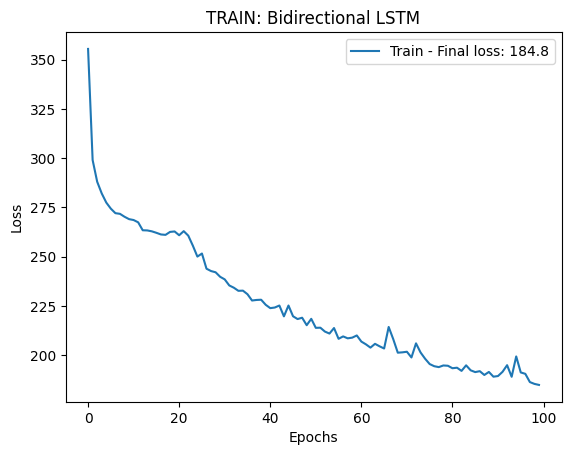

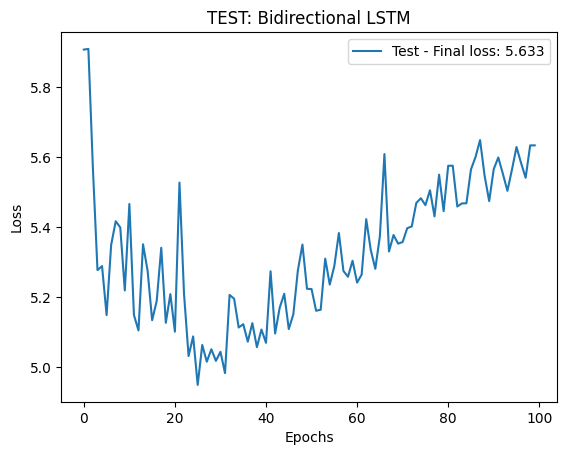

In [61]:
plot_loss("bilstm_epoch_loss_train.txt", "bilstm_epoch_loss_test.txt", epochs, "Bidirectional LSTM")

### Larger LSTM

LSTM model with 4 layers instead of 2, 256 hidden dims instead of 128, and 0.001 regularization instead of 0.0001.

The Bidirectional LSTM model was too computationally expensive, taking about 4-5 hours to complete 1 epoch. This model is more complex xthan the simple LSTM, but not bidirectional

#### Model Class Definitions

In [43]:
class AudioLargeLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers, dropout):
        super(AudioLargeLSTM, self).__init__()
        # LSTM with dropout
        self.lstm = nn.LSTM(input_size=input_dim,
                            hidden_size=hidden_dim,
                            num_layers=num_layers,
                            batch_first=True,
                            dropout=dropout)
        # Layer Normalization
        self.layernorm = nn.LayerNorm(hidden_dim)
        # Fully Connected Layer
        self.fc = nn.Linear(in_features=hidden_dim, out_features=output_dim)

    def forward(self, x):
        packed_output, _ = self.lstm(x)  # run LSTM layer
        output, _ = nn.utils.rnn.pad_packed_sequence(packed_output, batch_first=True)
        output_normalized = self.layernorm(output)
        return self.fc(output_normalized)  

#### Training

In [42]:
input_files = "./datashare/" + train_df["location"]
test_input_files = "./datashare/" + test_df['location']

train_chroma_ds = ChromaDataset(filepaths=input_files, chord_labels=train_df['chords'], chord_times=train_df['chords_time'], npy_dir='chroma_features', device=device)
test_chroma_ds = ChromaDataset(filepaths=test_input_files, chord_labels=test_df['chords'], chord_times=test_df['chords_time'], npy_dir='chroma_features_test', device=device)
train_dataloader = DataLoader(train_chroma_ds, batch_size=2048, shuffle=True, collate_fn=collate_fn)
test_dataloader = DataLoader(test_chroma_ds, batch_size=2048, shuffle=False, collate_fn=collate_fn)

# Examine dataloader
packed_sequences, packed_labels, lengths, _ = next(iter(train_dataloader))
packed_sequences, packed_labels, lengths = packed_sequences.to(device), packed_labels.to(device), lengths.to(device)
print("Packed sequences:", packed_sequences.data.shape)
print("Packed labels:", packed_labels.data.shape)  
print("Sequence lengths:", lengths[:10])

Packed sequences: torch.Size([630625, 12])
Packed labels: torch.Size([2048, 313])
Sequence lengths: tensor([313, 313, 313, 313, 313, 313, 313, 313, 313, 313], device='cuda:0')


In [44]:
input_dim = 12  # Chroma feature dimensions (12, 313) --> 12 pitches
hidden_dim = 256  # hyperparameter
output_dim = 174  # Number of Chords: 172 + <PAD> + <NULL>
num_layers = 4
dropout = 0.2

large_lstm_model = AudioLargeLSTM(input_dim, hidden_dim, output_dim, num_layers, dropout).to(device)
print(large_lstm_model)

AudioLargeLSTM(
  (lstm): LSTM(12, 256, num_layers=4, batch_first=True, dropout=0.2)
  (layernorm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (fc): Linear(in_features=256, out_features=174, bias=True)
)


In [45]:
# HYPERPARAMETERS
lr = 0.001
regularization = 0.001
loss_fn = nn.CrossEntropyLoss(ignore_index=chord_to_idx['<PAD>']).to(device)
start_epoch = 0
epochs = 100

# CHECKPOINTING
checkpoint_path = 'checkpoints/large_lstm_10.pt'
checkpoint = torch.load(checkpoint_path, map_location=device)

# Load checkpoint model state
large_lstm_model.load_state_dict(checkpoint['model_state_dict'])

# Load checkpoint optimizer state
opt = torch.optim.Adam(large_lstm_model.parameters(), lr=lr, weight_decay=regularization)
opt.load_state_dict(checkpoint['optimizer_state_dict'])

# Other checkpoint vals
start_epoch = checkpoint['epoch'] + 1
previous_loss = checkpoint['loss']
print("Previous Loss:", previous_loss)

Previous Loss: 80.23021292686462


In [ ]:
train_model(large_lstm_model, opt, loss_fn, train_dataloader, test_dataloader, output_dim, start_epoch, epochs, "checkpoints/large_lstm", 5, "large_epoch_loss")

Epoch 1, batch 1, Average Loss: 5.4291205
Epoch 1, batch 6, Average Loss: 4.6784756
Epoch 1, batch 11, Average Loss: 4.5116579
Epoch 1, batch 16, Average Loss: 4.4425498
Epoch 1, batch 21, Average Loss: 4.3990366
Epoch 1, batch 26, Average Loss: 4.3711814
---------- Epoch 1, Total Epoch Loss (Train): 113.6507173, Total Test Loss: 4.1564407 ----------
Epoch 2, batch 1, Average Loss: 4.1791730
Epoch 2, batch 6, Average Loss: 4.1935742
Epoch 2, batch 11, Average Loss: 4.1592542
Epoch 2, batch 16, Average Loss: 4.1138652
Epoch 2, batch 21, Average Loss: 4.0674797
Epoch 2, batch 26, Average Loss: 4.0576339
---------- Epoch 2, Total Epoch Loss (Train): 105.4984813, Total Test Loss: 3.7791548 ----------
Epoch 3, batch 1, Average Loss: 3.8644063
Epoch 3, batch 6, Average Loss: 3.8495295
Epoch 3, batch 11, Average Loss: 3.8013085
Epoch 3, batch 16, Average Loss: 3.7664345
Epoch 3, batch 21, Average Loss: 3.7246971
Epoch 3, batch 26, Average Loss: 3.6877559
---------- Epoch 3, Total Epoch Loss (

In [62]:
# Bigger Model
input_dim2 = 12  # Chroma feature dimensions (12, 313) --> 12 pitches
hidden_dim2 = 350  # hyperparameter
output_dim2 = 174  # Number of Chords: 172 + <PAD> + <NULL>
num_layers2 = 6
dropout2 = 0.2

large_lstm_model2 = AudioLargeLSTM(input_dim2, hidden_dim2, output_dim2, num_layers2, dropout2).to(device)
print(large_lstm_model2)

AudioLargeLSTM(
  (lstm): LSTM(12, 350, num_layers=6, batch_first=True, dropout=0.2)
  (layernorm): LayerNorm((350,), eps=1e-05, elementwise_affine=True)
  (fc): Linear(in_features=350, out_features=174, bias=True)
)


In [63]:
# HYPERPARAMETERS
lr2 = 0.001
regularization2 = 0.001
loss_fn2 = nn.CrossEntropyLoss(ignore_index=chord_to_idx['<PAD>']).to(device)
start_epoch2 = 0
epochs2 = 100

# CHECKPOINTING
# checkpoint_path = 'checkpoints/large_lstm_10.pt'
# checkpoint = torch.load(checkpoint_path, map_location=device)

# Load checkpoint model state
# large_lstm_model.load_state_dict(checkpoint['model_state_dict'])

# Load checkpoint optimizer state
opt2 = torch.optim.Adam(large_lstm_model2.parameters(), lr=lr2, weight_decay=regularization2)
# opt.load_state_dict(checkpoint['optimizer_state_dict'])

# Other checkpoint vals
# start_epoch = checkpoint['epoch'] + 1
# previous_loss = checkpoint['loss']
# print("Previous Loss:", previous_loss)

In [64]:
train_model(large_lstm_model2, opt2, loss_fn2, train_dataloader, test_dataloader, output_dim2, start_epoch2, epochs2, "checkpoints/large_lstm_2", 5, "large_2_epoch_loss")

OutOfMemoryError: CUDA out of memory. Tried to allocate 14.48 GiB. GPU 0 has a total capacity of 8.00 GiB of which 0 bytes is free. Of the allocated memory 5.93 GiB is allocated by PyTorch, and 2.96 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

#### Testing

In [56]:
sample_eval(large_lstm_model, test_dataloader, 0, 3, output_dim, loss_fn)

torch.Size([800, 313])
tensor(1, device='cuda:0')
Model output shape: torch.Size([800, 313, 174])
Modle idx shape: torch.Size([800, 313])
Label shape: torch.Size([800, 313])
Max classes (chord) per frame: ['<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', 'Ebm7', 'Ebm7', 'Ebm7', 'Ebm7', 'Ebm7', 'Ebm7', 'Ebm7', 'Ebm7', 'Ebm7', 'Ebm7', 'Ebm7', 'Ebm7', 'Ebm7', 'Ebm7', 'Ebm7', 'Ebm7', 'Ebm7', 'Ebm7', 'Ebm7', 'Ebm7', 'Ebm7', 'Ebm7', 'Ebm7', 'Ebm7', 'Ebm7', 'Ebm7', 'Ebm7', 'Ebm7', 'Ebm7', 'Ebm7', 'Ebm7', 'Ebm7', 'Ebm7', 'Ebm7', 'Ebm7', 'Ebm7', 'Ebm7', 'Ebm7', 'Ebm7', 'Ebm7', 'Ebm7', 'Ebm7', 'Ebm7', 'Ebm7', 'Ebm7', 'Ebm7', 'Ebm7', 'Ebm7', 'Ebm7', 'Ebm7', 'Ebm7', 'Ebm7', 'Ebm7', 'Ebm7', 'Ebm7', 'Ebm7', 'Ebm7', 'Ebm7', 'Ebm7', 'Ebm7', 'Bb6', 'Bb6', 'Bb6', 'Bb6', 'Bb6', 'Bb6', 'Faug', 'Faug', 'Faug', 'C#m7b5', 'C#m7b5', 'C#m7b5', 'C#m7b5'

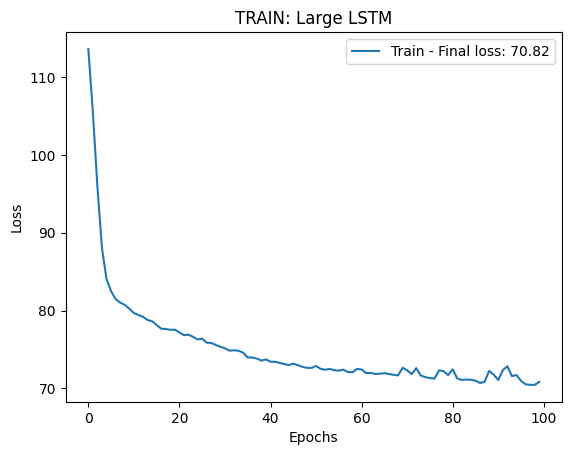

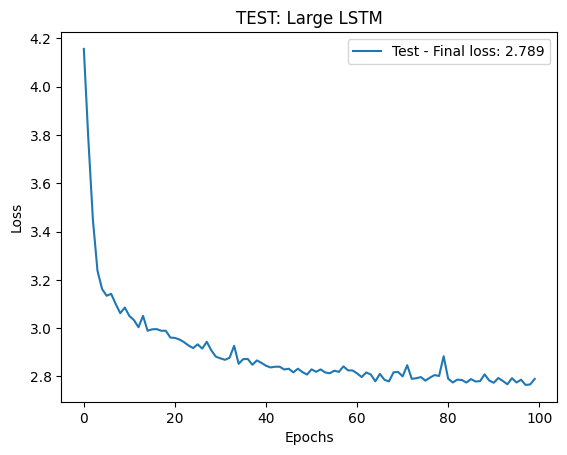

In [41]:
plot_loss("large_epoch_loss_train.txt", "large_epoch_loss_test.txt", epochs, "Large LSTM")

### Transformer w/ Attention

#### Model Class Definitions

In [ ]:
def attention(Q,K,V,mask=None):
  """
  Computes scaled dot-product attention.

  Compute scores as Q*K^T. 
  Optionally mask out score values to -1e9 where the mask is True.
  Divide by sqrt(d_k).
  Compute softmax on scores along the rows to obtain attention weights.
  Matrix multiply attention weights by values.

  Arguments:
    Q: queries [B,L,d_k]
    K: keys    [B,S,d_k]
    V: values  [B,S,d_v]
    mask: optional Boolean mask where True means hidden [B,L,S]

  Returns:
    Sequence of context vectors of shape [B,L,d_v]
  """
  d_k = Q.shape[-1]

  scores = torch.matmul(Q[0], K[0].T) / np.sqrt(d_k)

  if mask is not None:
    scores = scores.masked_fill(mask, -1e9)

  attention_weights = torch.softmax(scores, dim=-1)
  
  return torch.matmul(attention_weights, V)

class AttentionHead(nn.Module):
    def __init__(self,d_model,d_k):
        super().__init__()
        self.WQ = nn.Linear(d_model,d_k)
        self.WK = nn.Linear(d_model,d_k)
        self.WV = nn.Linear(d_model,d_k)

    def forward(self,Q,K,V,mask=None):
        """ Compute attention head.

            Project the input to queries, keys, and values, and then apply attention.
            Arguments:
                Q: queries [B,L,d_model]
                K: keys    [B,S,d_model]
                V: values  [B,L,d_model]
                mask: optional Boolean mask where True means hidden [B,L,S]
            Output:
                Context vectors [B,L,d_k]
        """
        # apply linear projections to queries, keys, and values followed by masked attention
        return attention(self.WQ(Q),self.WK(K),self.WV(V),mask=mask)

class MultiHeadAttention(nn.Module):
    def __init__(self,d_model=512,num_heads=8):
        super().__init__()
        self.heads = []
        d_k = d_model // num_heads
        self.heads = nn.ModuleList([AttentionHead(d_model,d_k) for head in range(num_heads)])
        self.W = nn.Linear(d_model,d_model)

    def forward(self,Q,K,V,mask=None):
        """ Compute multi-head attention.

            Applies attention num_heads times, concatenates the results, and applies a final linear projection.
            Arguments:
                Q: queries [B,L,d_model]
                K: keys    [B,S,d_model]
                V: values  [B,L,d_model]
                mask: optional Boolean mask where True means hidden [B,L,S]
            Output:
               result of multi-head attention [B,L,d_model]
        """
        # compute each attention head and concatenate
        h = torch.cat([head(Q,K,V,mask=mask) for head in self.heads],dim=-1)

        # apply output projection
        return self.W(h)

class SelfAttentionBlock(nn.Module):
    def __init__(self,d_model=512,num_heads=8,d_ff=2048):
        super().__init__()
        self.multi_head_attention = MultiHeadAttention(d_model,num_heads)
        self.ln1 = nn.LayerNorm(d_model)
        self.feed_forward = nn.Sequential(
            nn.Linear(d_model,d_ff),
            nn.ReLU(),
            nn.Linear(d_ff,d_model),
        )
        self.ln2 = nn.LayerNorm(d_model)

    def forward(self,x,mask=None):
        """ Compute self attention block.

            Arguments:
                x: input sequence [B,S,d_model]
                mask: optional Boolean mask where True means hidden [B,L,S]
            Output:
               result of attention block [B,L,d_model]
        """
        # compute multi-head attention
        mha = self.multi_head_attention(x,x,x,mask=mask)

        # residual connection and layer normalization
        x = self.ln1(mha + x)

        # compute feed-forward network
        ff = self.feed_forward(x)

        # residual connection and layer normalization
        x = self.ln2(ff + x)

        return x
    
class PositionalEmbedding(nn.Module):
    def __init__(self,max_seq_len,d_model):
        super().__init__()
        self.positional_embedding = nn.Embedding(max_seq_len,d_model)

    def forward(self,x):
        """ Adds a positional embedding.

            Arguments:
                x: input token sequence [B,S,d_model]
            Output:
               sequence with positional embedding added [B,S,d_model]
        """
        # get sequence length
        N = x.shape[1]

        # look up positional embedding vectors
        pe = self.positional_embedding(torch.arange(N).to(x.device)) # [N,d_model]

        # add to input
        x = x + pe[None,...] # [B,N,d_model]
        
        return x

class TransformerDecoder(nn.Module):
    def __init__(self,vocabulary_size,max_seq_len,
                      d_model=512,num_heads=8,d_ff=2048,num_blocks=6):
        super().__init__()
        self.blocks = nn.ModuleList([SelfAttentionBlock(d_model,num_heads,d_ff) for b in range(num_blocks)])
        self.token_embedding = nn.Embedding(vocabulary_size,d_model)
        self.output = nn.Linear(d_model,vocabulary_size)
        self.positional_embedding = PositionalEmbedding(max_seq_len,d_model)

    def forward(self,x,mask=None):
        """ Computes the decoded sequence:

            Convert input to token embedding vectors
            Add positional embedding to input
            Apply self-attention blocks with mask
            Compute output

            Arguments:
                x: input token sequence [B,S]
                mask: optional Boolean mask where false means hidden [B,S]
            Output:
               sequence predictions [B,S,output_size]
        """
        # look up embedding vectors for tokens
        x = self.token_embedding(x) # [B,S,d_model]

        # apply positional embedding
        x = self.positional_embedding(x) # [B,S,d_model]
        
        # apply sequence of masked self-attention blocks
        for block in self.blocks:
            x = block(x,mask=mask) # [B,S,d_model]
        
        # produce sequence of output vectors
        y = self.output(x) # [B,S,vocabulary_size]

        return y
    
def make_mask(seq_len):
    """ Make a mask for sequence prediction. """
    return (torch.triu(torch.ones((1,seq_len,seq_len)), diagonal=1)==1)

#### Training

#### Testing